# **LSTM Anomaly Detection on Hydrogen Trasport Network Testbed**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import os
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# **1. Load Data**

In [124]:
df_down = pd.read_parquet("./Dataset_Hydrogen/normality_scenarios/normality_gest_down.parquet")
df_center = pd.read_parquet("./Dataset_Hydrogen/normality_scenarios/normality_gest_center.parquet")
df_up = pd.read_parquet("./Dataset_Hydrogen/normality_scenarios/normality_gest_up.parquet")


ps11_val = df_down['PS9'].iloc[0]
ps12_val = df_down['PS10'].iloc[0]

# Funzione per inserire colonne dopo una colonna specifica
def insert_after(df, col_name, new_cols_dict):
    cols = list(df.columns)
    idx = cols.index(col_name) + 1
    for k, v in reversed(new_cols_dict.items()):
        df.insert(loc=idx, column=k, value=v)
    return df

# Aggiungi PS11 e PS12 a df_center
df_center = insert_after(df_center, "PS10", {
    "PS11": ps11_val,
    "PS12": ps12_val
})

# Aggiungi PS11 e PS12 a df_up
df_up = insert_after(df_up, "PS10", {
    "PS11": ps11_val,
    "PS12": ps12_val
})

# Aggiungi MFS4 = 0.0 dopo MFS3
df_center = insert_after(df_center, "MFS3", {
    "MFS4": 0.0
})

df_up = insert_after(df_up, "MFS3", {
    "MFS4": 0.0
})

display(df_down)
display(df_center.iloc[:, :12])
display(df_up.iloc[:, :12])

,PS1,PS2,PS3,PS4,PS5,PS6,PS7,PS8,PS9,PS10,...,MFS3,MFS4,label_anomaly,Leak,CompressorFault,CompressorDelay,leak_G3,leak_G4,leak_G5,leak_G6
Timestamp,,,,,,,,,,,,,,,,,,,,,
0.0,3.732251,3.703099,3.392205,3.339121,0.1,0.740000,3.403099,3.740000,3.339121,2.339121,...,4.840802,21.935845,0,0,0,0,0,0,0,0
1.0,3.732251,3.703099,3.392205,3.339121,0.1,0.740000,3.403099,3.740000,3.339121,2.339121,...,4.840802,21.935845,0,0,0,0,0,0,0,0
2.0,3.732251,3.703099,3.392205,3.339121,0.1,0.740000,3.403099,3.740000,3.339121,2.339121,...,4.840802,21.935845,0,0,0,0,0,0,0,0
3.0,3.732251,3.703099,3.392205,3.339121,0.1,0.740000,3.403099,3.740000,3.339121,2.339121,...,4.840802,21.935845,0,0,0,0,0,0,0,0
4.0,3.729055,3.703085,3.392204,3.339121,0.1,0.730000,3.403085,3.730000,3.339121,2.339121,...,4.838638,21.935845,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995.0,6.686597,6.639338,6.118258,6.008059,0.1,0.294710,6.139488,6.694710,6.008059,5.008059,...,6.256224,33.755054,0,0,0,0,0,0,0,0
19996.0,6.686457,6.639203,6.118114,6.007919,0.1,0.294568,6.139343,6.694568,6.007919,5.007919,...,6.255852,33.754507,0,0,0,0,0,0,0,0
19997.0,6.686317,6.639069,6.117970,6.007778,0.1,0.294426,6.139199,6.694426,6.007778,5.007778,...,6.255481,33.753960,0,0,0,0,0,0,0,0


,PS1,PS2,PS3,PS4,PS5,PS6,PS7,PS8,PS9,PS10,PS11,PS12
Timestamp,,,,,,,,,,,,
0.0,3.715877,3.609410,3.266582,3.019574,0.740000,3.309410,3.740000,3.019574,3.096788,3.266582,3.339121,2.339121
1.0,3.715877,3.609410,3.266582,3.019574,0.740000,3.309410,3.740000,3.019574,3.096788,3.266582,3.339121,2.339121
2.0,3.715877,3.609410,3.266582,3.019574,0.740000,3.309410,3.740000,3.019574,3.096788,3.266582,3.339121,2.339121
3.0,3.715877,3.609410,3.266582,3.019574,0.740000,3.309410,3.740000,3.019574,3.096788,3.266582,3.339121,2.339121
4.0,3.714536,3.609406,3.266582,3.019574,0.730000,3.309406,3.730000,3.019574,3.096788,3.266582,3.339121,2.339121
...,...,...,...,...,...,...,...,...,...,...,...,...
19995.0,6.671394,6.520610,5.945677,5.493800,0.294710,6.020760,6.694710,5.493799,5.635776,5.945677,3.339121,2.339121
19996.0,6.671258,6.520497,5.945558,5.493691,0.294568,6.020637,6.694568,5.493691,5.635665,5.945558,3.339121,2.339121
19997.0,6.671123,6.520385,5.945439,5.493582,0.294426,6.020515,6.694426,5.493582,5.635553,5.945439,3.339121,2.339121


,PS1,PS2,PS3,PS4,PS5,PS6,PS7,PS8,PS9,PS10,PS11,PS12
Timestamp,,,,,,,,,,,,
0.0,3.712462,3.589103,3.262219,3.258601,0.740000,3.289103,3.740000,3.262623,3.259004,3.262219,3.339121,2.339121
1.0,3.712462,3.589103,3.262219,3.258601,0.740000,3.289103,3.740000,3.262623,3.259004,3.262219,3.339121,2.339121
2.0,3.712462,3.589103,3.262219,3.258601,0.740000,3.289103,3.740000,3.262623,3.259004,3.262219,3.339121,2.339121
3.0,3.712462,3.589103,3.262219,3.258601,0.740000,3.289103,3.740000,3.262623,3.259004,3.262219,3.339121,2.339121
4.0,3.711224,3.589100,3.262219,3.258601,0.730000,3.289100,3.730000,3.262622,3.259004,3.262219,3.339121,2.339121
...,...,...,...,...,...,...,...,...,...,...,...,...
19995.0,6.667753,6.492079,5.945523,5.939211,0.294710,5.992229,6.694710,5.946162,5.939928,5.945523,3.339121,2.339121
19996.0,6.667619,6.491970,5.945406,5.939094,0.294568,5.992110,6.694568,5.946045,5.939811,5.945406,3.339121,2.339121
19997.0,6.667484,6.491861,5.945290,5.938977,0.294426,5.991991,6.694426,5.945928,5.939695,5.945290,3.339121,2.339121


In [125]:
def load_all_parquets(folder_path):
    dfs = {}
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".parquet"):
                full_path = os.path.join(root, file)
                df = pd.read_parquet(full_path)
                dfs[file] = df
    return dfs

# Percorsi
base_path = "./Dataset_Hydrogen/anomalous_scenarios/"
down_path = os.path.join(base_path, "anom_gestdown")
center_path = os.path.join(base_path, "anom_gestcent")
up_path = os.path.join(base_path, "anom_gestup")

# Caricamento
anom_gestdown_dfs = load_all_parquets(down_path)
anom_gestcenter_dfs = load_all_parquets(center_path)
anom_gestup_dfs = load_all_parquets(up_path)

# Funzione per aggiornare un DataFrame
def update_anomaly_df(ref_df, target_df):
    # Prendi valori costanti da PS9, PS10 nel file di riferimento
    ps11_val = ref_df['PS9'].iloc[0]
    ps12_val = ref_df['PS10'].iloc[0]

    # Costruisci colonne da aggiungere
    ps11_col = pd.Series(ps11_val, index=target_df.index)
    ps12_col = pd.Series(ps12_val, index=target_df.index)
    mfs4_col = pd.Series(0.0, index=target_df.index)

    # Inserisci PS11, PS12 dopo PS10
    ps10_idx = target_df.columns.get_loc('PS10')
    target_df.insert(ps10_idx + 1, 'PS11', ps11_col)
    target_df.insert(ps10_idx + 2, 'PS12', ps12_col)

    # Inserisci MFS4 dopo MFS3
    mfs3_idx = target_df.columns.get_loc('MFS3')
    target_df.insert(mfs3_idx + 1, 'MFS4', mfs4_col)

    return target_df

# Applicazione su tutti i file
for filename, df_down in anom_gestdown_dfs.items():
    if filename in anom_gestcenter_dfs:
        anom_gestcenter_dfs[filename] = update_anomaly_df(df_down, anom_gestcenter_dfs[filename])
    if filename in anom_gestup_dfs:
        anom_gestup_dfs[filename] = update_anomaly_df(df_down, anom_gestup_dfs[filename])
first_key = list(anom_gestcenter_dfs.keys())[2]
display(anom_gestcenter_dfs[first_key].iloc[:, :12])

,PS1,PS2,PS3,PS4,PS5,PS6,PS7,PS8,PS9,PS10,PS11,PS12
Timestamp,,,,,,,,,,,,
0.0,3.720959,3.623257,3.285089,3.066244,0.740508,3.324395,3.741443,3.066513,3.133241,3.285430,3.36615,2.365341
1.0,3.719821,3.624590,3.285368,3.065667,0.740440,3.324262,3.740677,3.065583,3.132792,3.285268,3.36615,2.365341
2.0,3.721167,3.624917,3.285904,3.065337,0.739805,3.323591,3.740805,3.065038,3.133766,3.286079,3.36615,2.365341
3.0,3.721774,3.624738,3.286251,3.065393,0.739655,3.322843,3.738922,3.063953,3.133901,3.285638,3.36615,2.365341
4.0,3.718985,3.623505,3.285402,3.066965,0.730412,3.324260,3.729027,3.066373,3.133117,3.285461,3.36615,2.365341
...,...,...,...,...,...,...,...,...,...,...,...,...
19995.0,6.633433,6.506462,5.940126,5.533846,0.296811,6.007032,6.694666,5.533631,5.659581,5.939038,3.36615,2.365341
19996.0,6.632919,6.505668,5.939482,5.535022,0.293428,6.006835,6.694354,5.533575,5.660148,5.941171,3.36615,2.365341
19997.0,6.632711,6.505859,5.939847,5.534344,0.293982,6.007361,6.693301,5.534534,5.660882,5.938058,3.36615,2.365341


# **2. Normalization and Partitioning of Data into Training, Validation, and Test Sets**

In [ ]:
PS_cols = [f"PS{i}" for i in range(1, 13)]
MFS_cols = [f"MFS{i}" for i in range(1, 5)]
label_col = "label_anomaly"

# === 2. COSTRUZIONE TRAIN SET ===

train_parts = []
for df in [df_down, df_center, df_up]:
    cols_present = [col for col in PS_cols + MFS_cols if col in df.columns]
    df_subset = df[cols_present + [label_col]].copy()
    
    # Aggiungi colonne mancanti come NaN
    for col in PS_cols + MFS_cols:
        if col not in df_subset.columns:
            df_subset[col] = pd.NA
            
    df_subset = df_subset[PS_cols + MFS_cols + [label_col]]
    train_parts.append(df_subset)

df_train = pd.concat(train_parts)

# === 3. COSTRUZIONE TEST SET ===

def create_test_set(dict_dfs, ps_cols, mfs_cols, label_col):
    test_dfs = []
    for df in dict_dfs.values():
        cols_present = [col for col in ps_cols + mfs_cols if col in df.columns]
        df_subset = df[cols_present + [label_col]].copy()
        
        for col in ps_cols + mfs_cols:
            if col not in df_subset.columns:
                df_subset[col] = pd.NA
                
        df_subset = df_subset[ps_cols + mfs_cols + [label_col]]
        test_dfs.append(df_subset)
    
    return pd.concat(test_dfs)

df_test_down = create_test_set(anom_gestdown_dfs, PS_cols, MFS_cols, label_col)
df_test_center = create_test_set(anom_gestcenter_dfs, PS_cols, MFS_cols, label_col)
df_test_up = create_test_set(anom_gestup_dfs, PS_cols, MFS_cols, label_col)

df_test = pd.concat([df_test_down, df_test_center, df_test_up], ignore_index=True)

# === 4. SCALING SEPARATO PS / MFS ===

scaler_ps = MinMaxScaler(feature_range=(0, 1))
scaler_mfs = MinMaxScaler(feature_range=(0, 1))

# Fit solo su training
X_train_ps = df_train[PS_cols].astype(float)
X_train_mfs = df_train[MFS_cols].astype(float)

X_train_ps_scaled = scaler_ps.fit_transform(X_train_ps)
X_train_mfs_scaled = scaler_mfs.fit_transform(X_train_mfs)

# Trasforma anche il test
X_test_ps = df_test[PS_cols].astype(float)
X_test_mfs = df_test[MFS_cols].astype(float)

X_test_ps_scaled = scaler_ps.transform(X_test_ps)
X_test_mfs_scaled = scaler_mfs.transform(X_test_mfs)

# === 5. CONCATENAZIONE FINALE ===

X_train = np.hstack([X_train_ps_scaled, X_train_mfs_scaled])
X_test = np.hstack([X_test_ps_scaled, X_test_mfs_scaled])

y_train = df_train[label_col].astype(int).values
y_test = df_test[label_col].astype(int).values

# === 6. Verifica shapes ===
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:", np.bincount(y_train))
print("y_test distribution:", np.bincount(y_test))

X_train shape: (60000, 16)
X_test shape: (2040000, 16)
y_train distribution: [40025 19975]
y_test distribution: [ 330144 1709856]


In [127]:
df_train, df_val = train_test_split(df_train.dropna(), test_size=0.2, shuffle=False) 


class PMDataset(Dataset):
    def __init__(self, data, seq_length, overlap=50):
        self.seq_length = seq_length
        self.overlap = overlap

        # Rimuove righe con NaN e converte in NumPy
        self.data = data.dropna().to_numpy(dtype=np.float32)

        # Calcola gli indici iniziali delle finestre
        self.indices = list(range(0, len(self.data) - seq_length - 1, seq_length - overlap))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start_idx = self.indices[idx]
        x = self.data[start_idx : start_idx + self.seq_length]
        y = self.data[start_idx + 1 : start_idx + self.seq_length + 1]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)
    
# === Parametri ===
seq_length = 100
overlap = 40
batch_size = 64


features_train = df_train.drop(columns=['label_anomaly'])
labels_train = df_train['label_anomaly']

features_val = df_val.drop(columns=['label_anomaly'])
labels_val = df_val['label_anomaly']

features_test = df_test.drop(columns=['label_anomaly'])
labels_test = df_test['label_anomaly']

# === Dataset ===
train_dataset = PMDataset(features_train, seq_length, overlap)
val_dataset   = PMDataset(features_val, seq_length, overlap)
test_dataset  = PMDataset(features_test, seq_length, overlap)

# === DataLoader ===
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# **3. LSTM Architecture**

In [128]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_rate, output_dim):
        super(LSTMModel, self).__init__()
        # Assuming input_shape is a tuple: (timesteps, features)
        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        #self.lstm2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        #self.dropout2 = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, output_dim)  

    def forward(self, x):
        # Apply the first LSTM
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        # Flatten the output for the Dense layer
        x = self.fc(x)
        return x

# **4. Let's Train LSTM**

In [ ]:
# Define model parameters
INPUT_DIM = features_train.shape[1]  # Number of features
HIDDEN_DIM = 10
DROPOUT_RATE = 0.0
OUTPUT_DIM = features_train.shape[1]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = LSTMModel(INPUT_DIM, HIDDEN_DIM, DROPOUT_RATE, OUTPUT_DIM).to(device)
criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
NUM_EPOCHS = 150
model.train()
loss_list = []

# Assumo che optimizer e criterion siano già definiti
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for i, (inputs, _) in enumerate(train_loader):
        inputs = inputs.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    epoch_loss /= len(train_loader)
    loss_list.append(epoch_loss)
    
    # Step dello scheduler basato sulla loss media dell'epoca
    scheduler.step(epoch_loss)
    
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {epoch_loss:.4f}')
    
# Salvataggio modello
model_path = "./Dataset_Hydrogen/lstm_weight_withMFS.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Epoch [1/150], Loss: 22.1059


Epoch [2/150], Loss: 21.3691
Epoch [3/150], Loss: 20.4727
Epoch [4/150], Loss: 18.8107
Epoch [5/150], Loss: 17.4777
Epoch [6/150], Loss: 16.3130
Epoch [7/150], Loss: 15.0559
Epoch [8/150], Loss: 13.9555
Epoch [9/150], Loss: 12.9680
Epoch [10/150], Loss: 12.0560
Epoch [11/150], Loss: 11.2572
Epoch [12/150], Loss: 10.6641
Epoch [13/150], Loss: 10.0128
Epoch [14/150], Loss: 9.5094
Epoch [15/150], Loss: 8.8382
Epoch [16/150], Loss: 8.2470
Epoch [17/150], Loss: 7.7382
Epoch [18/150], Loss: 7.2227
Epoch [19/150], Loss: 6.8281
Epoch [20/150], Loss: 6.4441
Epoch [21/150], Loss: 6.1296
Epoch [22/150], Loss: 5.7940
Epoch [23/150], Loss: 5.5581
Epoch [24/150], Loss: 5.2739
Epoch [25/150], Loss: 5.0605
Epoch [26/150], Loss: 4.8560
Epoch [27/150], Loss: 4.6862
Epoch [28/150], Loss: 4.4962
Epoch [29/150], Loss: 4.3400
Epoch [30/150], Loss: 4.1981
Epoch [31/150], Loss: 4.0648
Epoch [32/150], Loss: 3.9326
Epoch [33/150], Loss: 3.8248
Epoch [34/150], Loss: 3.6805
Epoch [35/150], Loss: 3.5526
Epoch [36/

# **5. Display Loss**

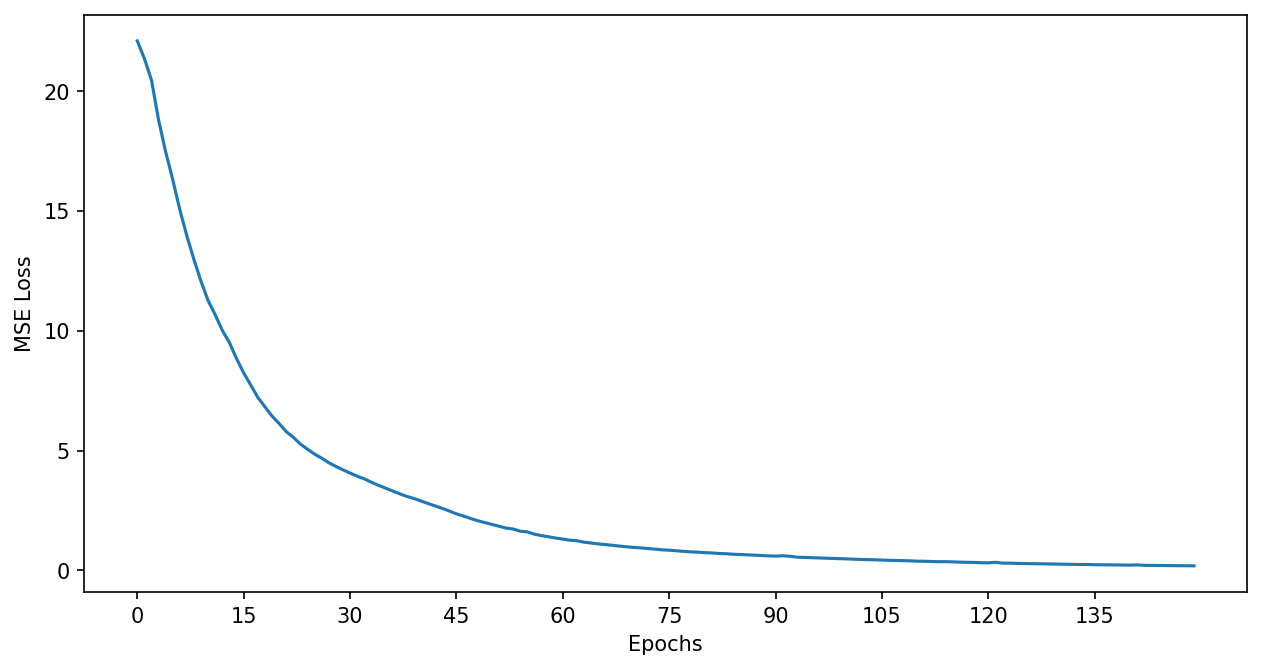

In [131]:
# Plot the results
plt.figure(figsize=(10, 5), dpi = 150)
plt.plot(loss_list)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
step = max(1, len(loss_list) // 10)
plt.xticks(np.arange(0, len(loss_list), step))
plt.show()

# **6. Validation Test Prediction**

In [ ]:
model.eval()
predictions = []
actuals = []
timestamps_list = []
# Recupera gli indici delle finestre usati nel validation dataset
val_indices = val_dataset.indices
val_data = df_val.dropna().to_numpy(dtype=np.float32)

with torch.no_grad():
    for i, (x_batch, y_batch) in enumerate(val_loader):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        output = model(x_batch)

        # output e y_batch: [batch_size, seq_length, n_features]
        output = output.cpu().numpy()
        y_batch = y_batch.cpu().numpy()

        for b in range(output.shape[0]):
            start_idx = val_indices[i * val_loader.batch_size + b]
            end_idx = start_idx + seq_length

            # Timestamp reali per questa finestra
            timestamps = df_val.index[start_idx + 1 : end_idx + 1]  # y è shiftato di 1

            predictions.append(output[b])   # shape: [seq_length, n_features]
            actuals.append(y_batch[b])
            timestamps_list.append(timestamps)

# Riformattazione finale
predictions = np.concatenate(predictions, axis=0)  # [total_samples, n_features]
actuals = np.concatenate(actuals, axis=0)
timestamps = np.concatenate(timestamps_list, axis=0)


print(predictions.shape)
print(actuals.shape)
print(len(timestamps))
print(df_val.shape[1])
assert predictions.shape == actuals.shape == (len(timestamps), predictions.shape[1])

# Metti tutto in DataFrame
results_df = pd.DataFrame(predictions, columns=[f'pred_PS{i+1}' for i in range(predictions.shape[1])])
for i in range(actuals.shape[1]):
    results_df[f'real_PS{i+1}'] = actuals[:, i]

results_df['timestamp'] = timestamps
results_df = results_df.set_index('timestamp')


for i in range(1, 13):
    ps_real = f'real_PS{i}'
    ps_pred = f'pred_PS{i}'
    quad_dev = f'quad_dev{i}'
    results_df[quad_dev] = (results_df[ps_real] - results_df[ps_pred]) ** 2

# Assumendo results_df il tuo DataFrame con indice float "timestamp" in secondi
start_date = pd.Timestamp("2025-06-01 00:00:00")

# Trasforma l'indice float in timedelta (secondi)
time_deltas = pd.to_timedelta(results_df.index, unit='s')

# Somma la data di partenza con i timedelta per creare un DatetimeIndex
new_index = start_date + time_deltas

# Assegna al DataFrame
results_df.index = new_index
results_df.index.name = 'timestamp'  # opzionale, per mantenere il nome

display(results_df)

mse_per_sensor = {}
for i in range(1, 13):
    col = f'quad_dev{i}'
    mse_per_sensor[col] = results_df[col].mean()

# Crea un DataFrame dai risultati
mse_df = pd.DataFrame.from_dict(mse_per_sensor, orient='index', columns=['MSE'])

# Rinomina l'indice per chiarezza (da quad_dev1 a PS1, ecc)
mse_df.index = [f'PS{i}' for i in range(1, 13)]

print(mse_df)

(19900, 16)
(19900, 16)
19900
17


,pred_PS1,pred_PS2,pred_PS3,pred_PS4,pred_PS5,pred_PS6,pred_PS7,pred_PS8,pred_PS9,pred_PS10,...,quad_dev3,quad_dev4,quad_dev5,quad_dev6,quad_dev7,quad_dev8,quad_dev9,quad_dev10,quad_dev11,quad_dev12
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-06-01 02:13:21,5.628528,5.208833,4.906473,4.484002,0.531271,4.741244,5.485357,4.855772,4.532623,4.544580,...,2.192489,3.595618,0.035619,2.886425,2.672058,2.347531,3.416477,3.395169,5.910205e-01,0.125383
2025-06-01 02:13:22,6.915701,6.527319,6.110072,5.628770,0.672300,5.909851,6.778426,5.967618,5.699462,5.708386,...,0.076783,0.564654,0.002275,0.281252,0.116673,0.176660,0.464473,0.460748,1.220437e-02,0.002647
2025-06-01 02:13:23,7.113962,6.729770,6.295221,5.805377,0.694165,6.090482,6.978165,6.138501,5.879126,5.888241,...,0.008453,0.330417,0.000667,0.122285,0.020117,0.062209,0.251854,0.248921,8.472953e-05,0.013003
2025-06-01 02:13:24,7.141606,6.757946,6.321063,5.830235,0.697274,6.116015,7.006109,6.162276,5.904425,5.913609,...,0.004368,0.302447,0.000516,0.105073,0.012971,0.050911,0.227092,0.224243,2.473482e-05,0.015038
2025-06-01 02:13:25,7.145450,6.761863,6.324672,5.833762,0.697723,6.119668,7.010006,6.165568,5.908029,5.917223,...,0.003903,0.298570,0.000496,0.102713,0.012099,0.049431,0.223661,0.220824,4.859985e-05,0.015319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-01 05:32:56,7.138711,6.753494,6.316036,5.822011,0.696175,6.106174,7.003313,6.161288,5.894861,5.903803,...,0.135639,0.014261,0.159015,0.012473,0.093577,0.045328,0.002236,0.001931,3.751530e-07,0.016259
2025-06-01 05:32:57,7.138709,6.753492,6.316033,5.822008,0.696174,6.106171,7.003310,6.161286,5.894858,5.903800,...,0.135723,0.014234,0.159128,0.012499,0.093663,0.045377,0.002225,0.001921,3.734027e-07,0.016259
2025-06-01 05:32:58,7.138708,6.753489,6.316031,5.822004,0.696174,6.106167,7.003308,6.161285,5.894854,5.903797,...,0.135807,0.014207,0.159241,0.012525,0.093749,0.045427,0.002215,0.001911,3.707848e-07,0.016259


           MSE
PS1   0.045082
PS2   0.032878
PS3   0.032083
PS4   0.249300
PS5   0.012852
PS6   0.089393
PS7   0.040922
PS8   0.049384
PS9   0.186897
PS10  0.184421
PS11  0.006079
PS12  0.016491


# **7. Test and Inference**

- Threshold based on MSE reconstruction error  
- Threshold based on Mahalanobis distance between train and test distributions

Testing k = 0.50, Threshold = 0.119623
AUC: 0.6909
Testing k = 4.50, Threshold = 0.446082
AUC: 0.6909
Testing k = 8.50, Threshold = 0.772542
AUC: 0.6909
Testing k = 12.50, Threshold = 1.099002
AUC: 0.6909
Testing k = 16.50, Threshold = 1.425461
AUC: 0.6909


<Figure size 1000x800 with 0 Axes>

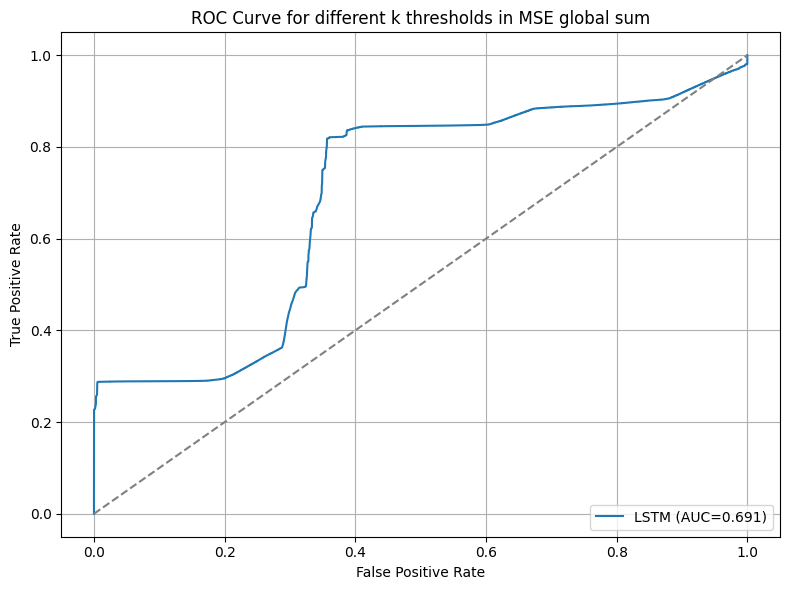


Best k: 0.50 with AUC: 0.6909

=== Classification Report for best k ===
              precision    recall  f1-score   support

      Normal       0.42      0.59      0.49    550199
     Anomaly       0.91      0.84      0.88   2849701

    accuracy                           0.80   3399900
   macro avg       0.67      0.72      0.68   3399900
weighted avg       0.83      0.80      0.82   3399900

=== Confusion Matrix for best k ===
[[ 323370  226829]
 [ 443088 2406613]]


In [ ]:
# Funzione per inferenza sul test_loader e calcolo risultati
def run_inference(model, test_loader, test_indices, df_test, seq_length, device):
    model.eval()
    predictions = []
    actuals = []
    timestamps_list = []

    with torch.no_grad():
        for i, (x_batch, y_batch) in enumerate(test_loader):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            output = model(x_batch)
            output = output.cpu().numpy()
            y_batch = y_batch.cpu().numpy()

            for b in range(output.shape[0]):
                start_idx = test_indices[i * test_loader.batch_size + b]
                end_idx = start_idx + seq_length
                # Nota: attenzione che l'indice deve essere coerente con dimensioni dati
                timestamps = df_test.index[start_idx + 1 : end_idx + 1]
                predictions.append(output[b])
                actuals.append(y_batch[b])
                timestamps_list.append(timestamps)

    predictions_arr = np.concatenate(predictions, axis=0)
    actuals_arr = np.concatenate(actuals, axis=0)
    timestamps_arr = np.concatenate(timestamps_list, axis=0)

    return predictions_arr, actuals_arr, timestamps_arr


# --- Calcolo media e std dei MSE sul validation set ---
mean_mse = mse_df['MSE'].mean()
std_mse = mse_df['MSE'].std()

# Range di k da testare (esempio: da 0.5 a 20 con step 4)
k_values = np.arange(0.5, 20.1, 4)

best_auc = 0
best_k = None
best_results_df1 = None


best_fpr = None
best_tpr = None
best_thresholds = None


test_indices = test_dataset.indices
test_data = df_test.dropna().to_numpy(dtype=np.float32)

plt.figure(figsize=(10, 8))

for k in k_values:
    threshold = mean_mse + k * std_mse
    print(f"Testing k = {k:.2f}, Threshold = {threshold:.6f}")

    # Esegui inferenza
    predictions_arr, actuals_arr, timestamps_arr = run_inference(
        model, test_loader, test_indices, df_test, seq_length, device
    )

    # Costruzione DataFrame risultati
    results_df1 = pd.DataFrame(
        predictions_arr, columns=[f'pred_PS{i+1}' for i in range(predictions_arr.shape[1])]
    )
    for i in range(actuals_arr.shape[1]):
        results_df1[f'real_PS{i+1}'] = actuals_arr[:, i]

    results_df1['timestamp'] = timestamps_arr
    results_df1 = results_df1.set_index('timestamp')

    # Calcolo deviazioni quadratiche per sensore
    quad_devs = []
    for i in range(1, 13):
        real = f'real_PS{i}'
        pred = f'pred_PS{i}'
        dev = (results_df1[real] - results_df1[pred]) ** 2
        results_df1[f'quad_dev{i}'] = dev
        quad_devs.append(dev)

    # Media MSE su tutti i 12 sensori
    results_df1['quad_dev_total'] = sum(quad_devs) / len(quad_devs)

    # Ricostruzione indice datetime da secondi (assunto già in index)
    start_date = pd.Timestamp("2025-06-01 00:00:00")
    time_deltas = pd.to_timedelta(results_df1.index, unit='s')
    results_df1.index = start_date + time_deltas
    results_df1.index.name = 'timestamp'

    # Classificazione basata su threshold globale
    results_df1['anomaly_global'] = (results_df1['quad_dev_total'] > threshold).astype(int)

    # Allineamento etichette reali (true labels)
    aligned_labels = []
    for start_idx in test_indices:
        label_window = labels_test[start_idx + 1 : start_idx + seq_length + 1]
        aligned_labels.append(label_window)
    aligned_labels = np.concatenate(aligned_labels, axis=0)
    results_df1['true_label'] = aligned_labels

    # Calcolo metriche
    y_true = results_df1['true_label'].to_numpy()
    y_pred = results_df1['anomaly_global'].to_numpy()
    y_scores = results_df1['quad_dev_total'].to_numpy()

    auc_score = roc_auc_score(y_true, y_scores)
    print(f"AUC: {auc_score:.4f}")

    
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    if auc_score > best_auc:
        best_auc = auc_score
        best_k = k
        best_results_df1 = results_df1.copy()
        best_fpr = fpr
        best_tpr = tpr
        best_thresholds = thresholds

    # Plot ROC curve per ogni k

plt.figure(figsize=(8, 6))
plt.plot(best_fpr, best_tpr, label=f'LSTM (AUC={best_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for different k thresholds in MSE global sum')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


roc_data = np.vstack([best_fpr, best_tpr, best_thresholds]).T
np.savetxt('roc_best_lstm_mse_global_sum_withMFS.txt', roc_data, delimiter=',', header='FPR,TPR,Threshold', comments='')

print(f"\nBest k: {best_k:.2f} with AUC: {best_auc:.4f}\n")

print("=== Classification Report for best k ===")
print(classification_report(best_results_df1['true_label'], best_results_df1['anomaly_global'], target_names=["Normal", "Anomaly"]))

print("=== Confusion Matrix for best k ===")
print(confusion_matrix(best_results_df1['true_label'], best_results_df1['anomaly_global']))

Testing k = 0.50, Threshold (Mahalanobis) = 11592.436336
A   UC: 0.6429
Testing k = 4.50, Threshold (Mahalanobis) = 43778.724962
A   UC: 0.6429
Testing k = 8.50, Threshold (Mahalanobis) = 75965.013587
A   UC: 0.6429
Testing k = 12.50, Threshold (Mahalanobis) = 108151.302212
A   UC: 0.6429
Testing k = 16.50, Threshold (Mahalanobis) = 140337.590838
A   UC: 0.6429


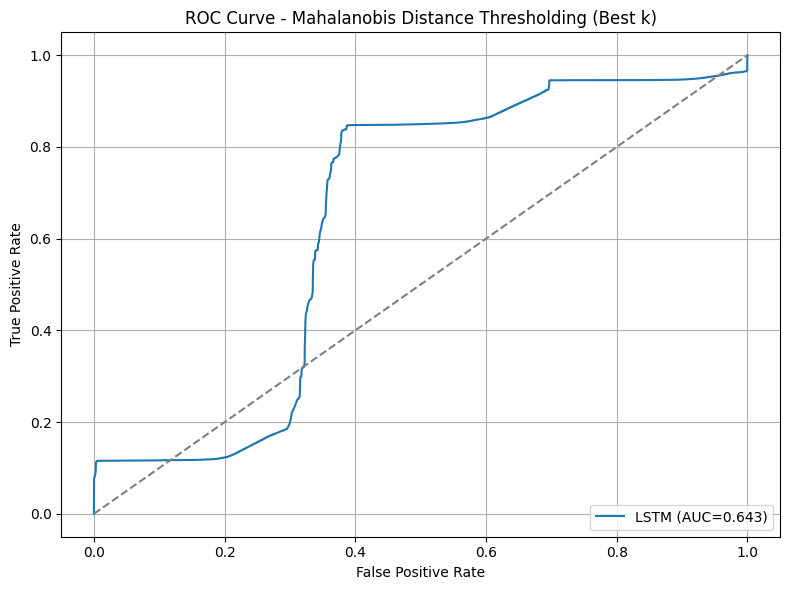


Best k: 0.50 with AUC: 0.6429

=== Classification Report for best k ===
              precision    recall  f1-score   support

      Normal       0.16      0.68      0.26    550199
     Anomaly       0.83      0.30      0.44   2849701

    accuracy                           0.36   3399900
   macro avg       0.49      0.49      0.35   3399900
weighted avg       0.72      0.36      0.41   3399900

=== Confusion Matrix for best k ===
[[ 376453  173746]
 [2003849  845852]]


In [134]:
# --- Funzione distanza di Mahalanobis ---
def mahalanobis_dist(x, mean, inv_cov):
    delta = x - mean
    return np.sqrt(np.dot(np.dot(delta, inv_cov), delta.T))

# --- Estrazione errori quadratici (MSE) su training set ---
train_quad_devs = []
for i in range(1, 13):
    real = f'real_PS{i}'
    pred = f'pred_PS{i}'
    dev = (results_df[real] - results_df[pred]) ** 2
    results_df[f'quad_dev{i}'] = dev
    train_quad_devs.append(dev)

train_errors = np.vstack(train_quad_devs).T  # shape (N_samples, 12)

# --- Calcolo media e matrice di covarianza degli errori sul training set ---
mean_vec = np.mean(train_errors, axis=0)
cov_mat = np.cov(train_errors, rowvar=False)
inv_cov_mat = np.linalg.inv(cov_mat + 1e-6 * np.eye(cov_mat.shape[0]))  # regolarizzazione

# --- Inferenza sul test set e calcolo errori quadratici ---
model.eval()
predictions = []
actuals = []
timestamps_list = []

test_indices = test_dataset.indices

with torch.no_grad():
    for i, (x_batch, y_batch) in enumerate(test_loader):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        output = model(x_batch)

        output = output.cpu().numpy()
        y_batch = y_batch.cpu().numpy()

        for b in range(output.shape[0]):
            start_idx = test_indices[i * test_loader.batch_size + b]
            end_idx = start_idx + seq_length
            timestamps = df_test.index[start_idx + 1 : end_idx + 1]
            predictions.append(output[b])
            actuals.append(y_batch[b])
            timestamps_list.append(timestamps)

predictions_arr = np.concatenate(predictions, axis=0)
actuals_arr = np.concatenate(actuals, axis=0)
timestamps_arr = np.concatenate(timestamps_list, axis=0)

results_df1 = pd.DataFrame(predictions_arr, columns=[f'pred_PS{i+1}' for i in range(predictions_arr.shape[1])])
for i in range(actuals_arr.shape[1]):
    results_df1[f'real_PS{i+1}'] = actuals_arr[:, i]
results_df1['timestamp'] = timestamps_arr
results_df1 = results_df1.set_index('timestamp')

quad_devs = []
for i in range(1, 13):
    real = f'real_PS{i}'
    pred = f'pred_PS{i}'
    dev = (results_df1[real] - results_df1[pred]) ** 2
    results_df1[f'quad_dev{i}'] = dev
    quad_devs.append(dev)

test_errors = np.vstack(quad_devs).T  # shape (N_samples, 12)

# --- Calcolo distanza Mahalanobis per ogni punto test ---
mahalanobis_scores = np.array([mahalanobis_dist(x, mean_vec, inv_cov_mat) for x in test_errors])
results_df1['mahalanobis'] = mahalanobis_scores

# --- Statistiche di Mahalanobis per soglia ---
mean_m = mahalanobis_scores.mean()
std_m = mahalanobis_scores.std()

# Prova diversi k per soglia sulla distanza Mahalanobis
k_values = np.arange(0.5, 20.1, 4)

best_auc = 0
best_k = None
best_results_df1 = None

best_fpr = None
best_tpr = None
best_thresholds = None


aligned_labels = []
for start_idx in test_indices:
    label_window = labels_test[start_idx + 1 : start_idx + seq_length + 1]
    aligned_labels.append(label_window)
aligned_labels = np.concatenate(aligned_labels, axis=0)
results_df1['true_label'] = aligned_labels

y_true = results_df1['true_label'].to_numpy()
y_scores = results_df1['mahalanobis'].to_numpy()

for k in k_values:
    threshold = mean_m + k * std_m
    print(f"Testing k = {k:.2f}, Threshold (Mahalanobis) = {threshold:.6f}")

    results_df1['anomaly_global'] = (results_df1['mahalanobis'] > threshold).astype(int)
    y_pred = results_df1['anomaly_global'].to_numpy()

    auc_score = roc_auc_score(y_true, y_scores)
    print(f"A   UC: {auc_score:.4f}")
    fpr, tpr, thresholds  = roc_curve(y_true, y_scores)
    

    if auc_score > best_auc:
        best_auc = auc_score
        best_k = k
        best_results_df1 = results_df1.copy()
        best_fpr = fpr
        best_tpr = tpr
        best_thresholds = thresholds

   

plt.figure(figsize=(8, 6))
plt.plot(best_fpr, best_tpr, label=f'LSTM (AUC={best_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Mahalanobis Distance Thresholding (Best k)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Salvataggio ROC curve best k su file txt (CSV semplice)
roc_data = np.vstack([best_fpr, best_tpr, best_thresholds]).T
np.savetxt('roc_best_lstm_mahalanobis_withMFS.txt', roc_data, delimiter=',', header='FPR,TPR,Threshold', comments='')

print(f"\nBest k: {best_k:.2f} with AUC: {best_auc:.4f}\n")
print("=== Classification Report for best k ===")
print(classification_report(best_results_df1['true_label'], best_results_df1['anomaly_global'], target_names=["Normal", "Anomaly"]))
print("=== Confusion Matrix for best k ===")
print(confusion_matrix(best_results_df1['true_label'], best_results_df1['anomaly_global']))